In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv("finalReviews.csv")
df.head()

,review,label
0,There isn't too much in the way of suspense or...,1
1,"I cried and laughed and blah, blah, blah. CGI ...",1
2,Not as good as infinity war..,1
3,First review from me. This film deserves it. A...,1
4,This film is an emotional rollercoaster with s...,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  302 non-null    object
 1   label   302 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 4.8+ KB


In [5]:
df.describe()

,label
count,302.000000
mean,0.562914
std,0.496849
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [6]:
df.shape

(302, 2)

In [7]:
df.isnull().sum()

,0
review,0
label,0


In [8]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [9]:
ps = PorterStemmer()
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    words = text.split()
    words = [word for word in words if word not in stopwords.words('english')]
    words = [ps.stem(word) for word in words]
    return " ".join(words)

In [10]:
df["review"] = df["review"].apply(clean_text)
print(df.head())

                                              review  label
0  isnt much way suspens surpris come stori shock...      1
1  cri laugh blah blah blah cgi great cant get pa...      1
2                                     good infin war      1
3  first review film deserv superhero film marvel...      1
4  film emot rollercoast coolest superhero plot l...      1


In [11]:
X = df["review"]
y = df["label"]

In [12]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(X)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [15]:
y_pred = model.predict(X_test)

In [16]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

Accuracy : 0.819672131147541


[[18  7]
 [ 4 32]]


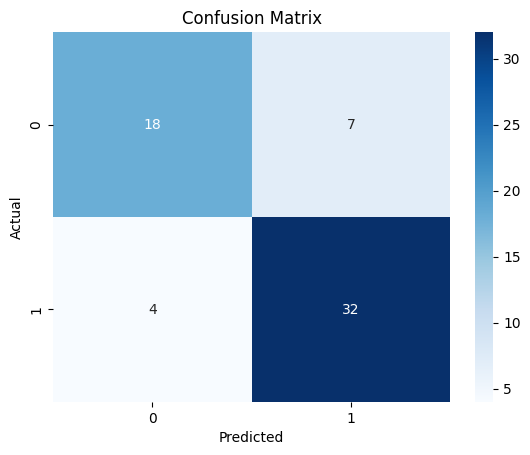

In [17]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.72      0.77        25
           1       0.82      0.89      0.85        36

    accuracy                           0.82        61
   macro avg       0.82      0.80      0.81        61
weighted avg       0.82      0.82      0.82        61



In [19]:
review = ["This movie was amazing and full of action"]
review = [clean_text(i) for i in review]
review = tfidf.transform(review)
prediction = model.predict(review)
if prediction[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")

Positive Review
